<div style="font-family: 'Segoe UI', Arial, sans-serif; 
            border-left: 5px solid #1f77b4; 
            padding: 20px; 
            background-color: #f8f9fa; 
            border-radius: 4px; 
            box-shadow: 0 1px 3px rgba(0,0,0,0.05); 
            max-width: 800px; 
            margin-bottom: 25px;">
    
<h1 style="color: #212529; margin-top: 0; margin-bottom: 5px; font-size: 26px; font-weight: 700;">
    Part I: Simplified CMS Open Data
</h1>
<br>
<p style="color: #6c757d; margin-top: 0; margin-bottom: 20px; font-size: 18px; font-weight: bold;">
    Notebook 2: Exploratory Data Analysis
</p>

<hr style="border: 0; border-top: 1px solid #dee2e6; margin-bottom: 15px;">

<table style="border-collapse: collapse; width: 100%; font-size: 14px; line-height: 1.6;">
    <tr>
        <td style="padding: 4px 0; width: 150px; font-weight: bold; color: #495057;">Author:</td>
        <td style="padding: 4px 0; color: #212529;">Uditangshu Roy</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Affiliation:</td>
        <td style="padding: 4px 0; color: #212529;">Undergraduate, Department of Physics and Astronomy, The University of Manchester</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Contact:</td>
        <td style="padding: 4px 0; color: #1f77b4; text-decoration: none;">roy.uditangshu@gmail.com</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Date:</td>
        <td style="padding: 4px 0; color: #212529;">August 2026</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Dataset Source:</td>
        <td style="padding: 4px 0; color: #212529;">CERN Open Data: <i> Z to two muons from 2011</i>. McCauley, T. Recorded 2011. Published 2019.</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">Software Env.:</td>
        <td style="padding: 4px 0; color: #212529;">Python 3.x, Pandas, Matplotlib, NumPy, Pathlib, IPython</td>
    </tr>
    <tr>
        <td style="padding: 4px 0; font-weight: bold; color: #495057;">ORCID:</td>
        <td style="padding: 4px 0; color: #212529; font-family: monospace; letter-spacing: 0.5px;"><a href="https://orcid.org/0009-0005-7992-3549">0009-0005-7992-3549</a></td>
    </tr>
</table>
</div>

## 1. &nbsp; Introduction

Before reconstructing the invariant mass of the $Z$-boson, it is important to examine the reconstructed properties of the individual muons contained within the dataset. Exploratory data analysis provides an opportunity to understand the distributions of the measured observables, identify any unexpected behaviour, and verify that the selected events are consistent with the expected characteristics of high-energy proton–proton collisions. The results presented in this notebook also provide valuable physical intuition for the kinematic quantities that are subsequently used in the invariant mass calculation.

In [1]:
#Import libraries and modules

import sys
from pathlib import Path
from IPython.display import display, HTML
import pandas as pd

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.plotting import (
    set_plot_style,
    plot_overlay_histogram,
    plot_scatter,
    plot_bar,
    plot_correlation_matrix
)

from src.utilities import (
    KINEMATIC_COLUMNS,
    TRACK_COLUMNS,
    )

set_plot_style()  #sets matplotlib rc-params

#Center-align outputs
display(HTML("""
<style>
.jp-OutputArea-output {
    display: flex;
    justify-content: center;
    align-items: center;
}
</style>
"""))

In [2]:
#Load Dataset
zmumu = pd.read_csv("../../data/raw/simplified/zmumu_10k.csv")

## 2. &nbsp; Exploratory Data Analysis

### 2.1 &nbsp; Transverse Momentum
The transverse momentum $(p_T)$ measures the component of a particle's momentum perpendicular to the beam axis. Since the initial momentum along the transverse plane is approximately zero in proton–proton collisions, transverse momentum is one of the most important observables in collider physics. It is widely used in event selection and forms a key component of the invariant mass reconstruction performed later in this project.

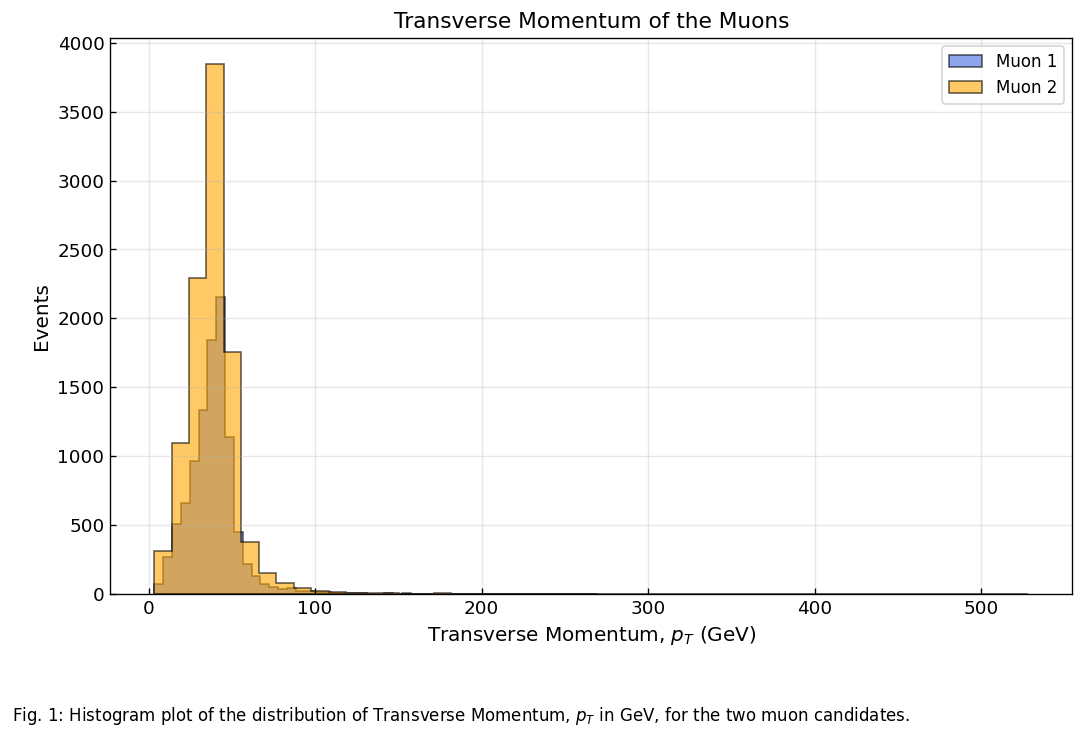

In [3]:
plot_overlay_histogram(
    zmumu["pt1"],
    zmumu["pt2"],
    bins=50,
    xlabel=r"Transverse Momentum, $p_T$ (GeV)",
    title="Transverse Momentum of the Muons",
    caption=r"Fig. 1: Histogram plot of the distribution of Transverse Momentum, $p_T$ in GeV, for the two muon candidates.",
    save_path="../../figures/z_mumu_dimuon_transverse_momenta_part_1.png",
    alt_caption=r"Histogram plot of the distribution of Transverse Momentum, $p_T$ in GeV, for the two muon candidates, both leading and sub-leading muons."
)

The transverse momentum distributions of the two reconstructed muons are broadly similar, as expected for particles originating from the same parent boson. Most events contain muons with transverse momenta between approximately 20 and 60 GeV, while progressively fewer events are observed at larger values. A small number of events populate the high-energy tail, corresponding to more energetic collision configurations. However, muon 2 shows a noticeably higher peak around 40–50 GeV, and overall, if one were to draw a smooth curve around the tops of the bars, the distribution for muon 2 would lie slightly above that of muon 1. This suggests a modest difference in the shape of the two distributions, although the overall event selection still appears broadly symmetric.

### 2.2 &nbsp; Pseudorapidity

Pseudorapidity $(\eta)$ describes the direction of a particle relative to the beam axis and is one of the principal coordinates used in collider physics. Unlike the transverse momentum, which characterises the particle's motion perpendicular to the beam, pseudorapidity indicates how far a particle is emitted towards the forward or backward regions of the detector. The CMS detector provides reliable muon reconstruction only within a finite range of pseudorapidity, known as the detector acceptance, making this variable particularly important for understanding which collision products can be measured accurately. Examining the pseudorapidity distribution therefore provides insight into both the geometry of the detector and the angular distribution of the reconstructed muons within the selected event sample.

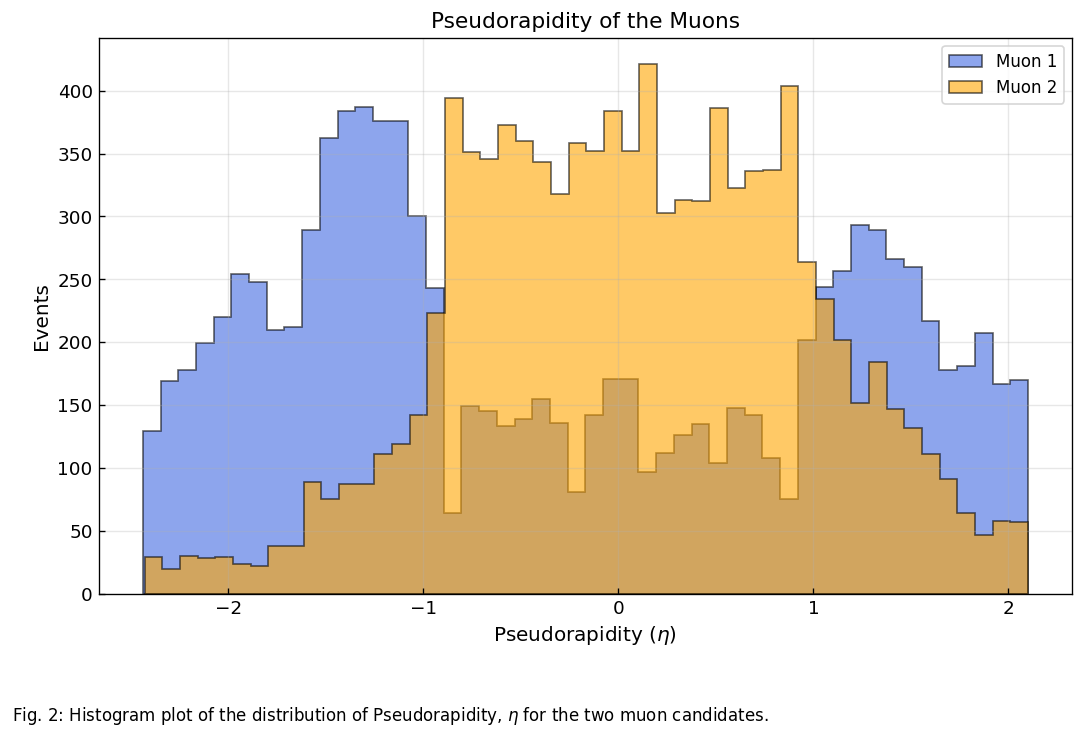

In [4]:
plot_overlay_histogram(
    zmumu["eta1"],
    zmumu["eta2"],
    bins=50,
    xlabel=r"Pseudorapidity $(\eta)$",
    title="Pseudorapidity of the Muons",
    caption=r"Fig. 2: Histogram plot of the distribution of Pseudorapidity, $\eta$ for the two muon candidates.",
    save_path="../../figures/z_mumu_dimuon_pseudorapidity_part_1.png",
    alt_caption=r"Histogram plot of the distribution of Pseudorapidity, $\eta$ for the two muon candidates, both leading and sub-leading muons."
)

The pseudorapidity distributions are concentrated within the fiducial acceptance of the CMS detector and are approximately symmetric about zero. This behaviour is expected for proton–proton collisions, where no preferred direction exists along the beam axis once detector acceptance is taken into account. The absence of unexpected peaks or discontinuities provides additional confidence in the quality of the reconstructed event sample.

### 2.3 &nbsp; Azimuthal Angle

The azimuthal angle $(\phi)$ specifies the direction of a particle within the plane perpendicular to the beam axis. Together with the transverse momentum and pseudorapidity, it forms one of the principal coordinates used to describe particle trajectories in collider experiments. Since the LHC collides protons head-on, no preferred direction exists in the transverse plane, and the azimuthal angle therefore provides a useful check for potential detector asymmetries or biases in the event selection. Examining its distribution helps verify that the reconstructed muons are distributed uniformly around the beam axis, as expected for an unbiased sample of proton–proton collision events.

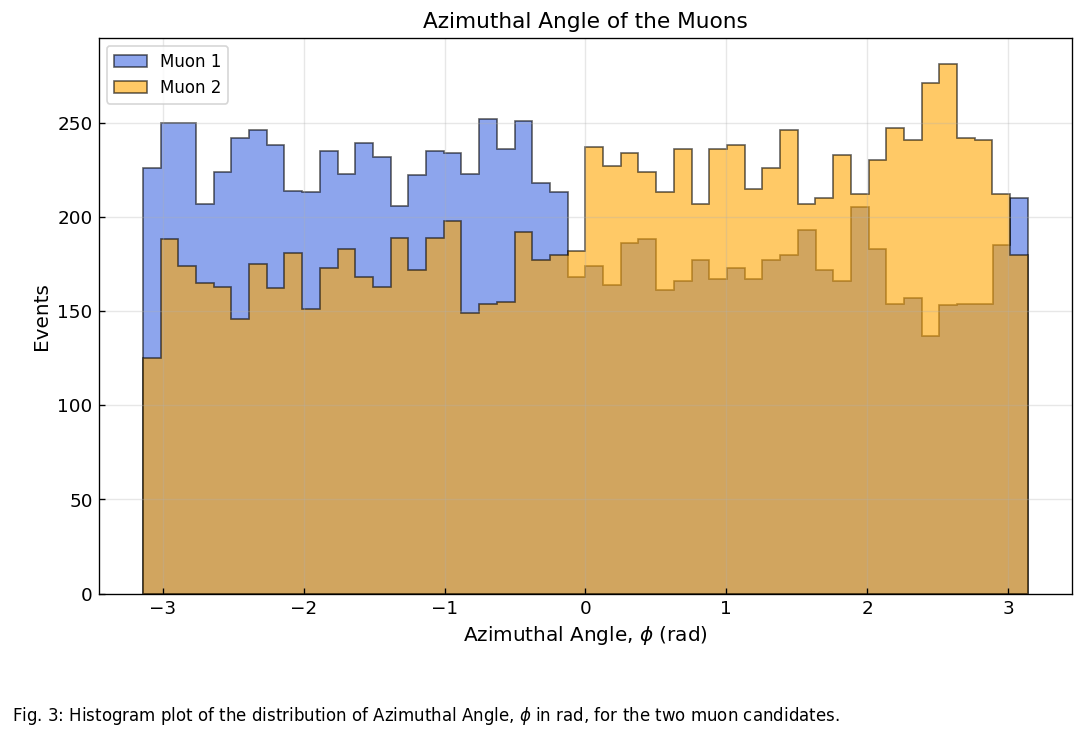

In [5]:
plot_overlay_histogram(
    zmumu["phi1"],
    zmumu["phi2"],
    bins=50,
    xlabel=r"Azimuthal Angle, $\phi$ (rad)",
    title="Azimuthal Angle of the Muons",
    caption=r"Fig. 3: Histogram plot of the distribution of Azimuthal Angle, $\phi$ in rad, for the two muon candidates.",
    save_path="../../figures/z_mumu_dimuon_azimuthal_angle_part_1.png",
    alt_caption=r"Histogram plot of the distribution of Azimuthal Angle, $\phi$ in rad, for the two muon candidates, both leading and sub-leading muons."
)

The azimuthal angle is observed to span the full interval between $-\pi$ and $\pi$, with no preferred orientation in the transverse plane. This approximately uniform distribution reflects the rotational symmetry of the detector around the beam axis and indicates that no significant directional bias is present within the selected events.

### 2.4 &nbsp; Charge

The electric charge is a fundamental property of every reconstructed particle and provides an important means of identifying the underlying interaction. Muons possess a charge of either $+1$ or $-1$ (in units of the elementary charge), and the decay of a neutral $Z$ boson produces a pair of oppositely charged muons. Examining the charge distribution therefore provides a simple but valuable validation of the reconstructed event sample and confirms that the recorded particles are consistent with the expected decay topology.

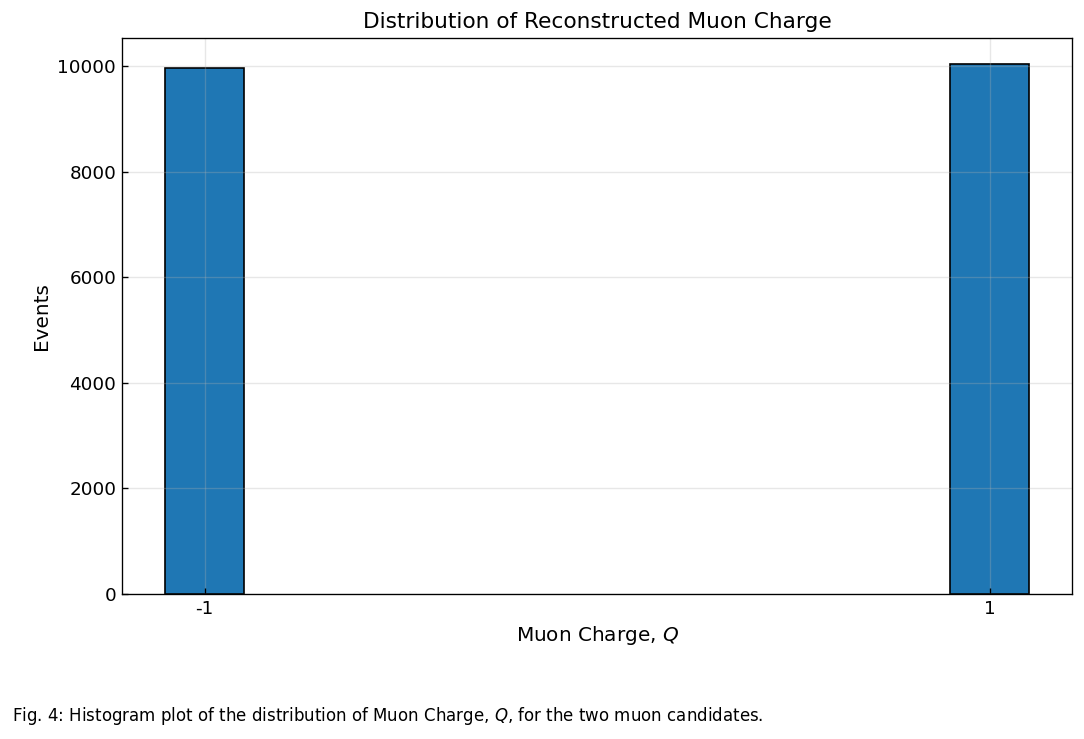

In [6]:
charges = pd.concat([
    zmumu["Q1"],
    zmumu["Q2"]
])

charge_counts = charges.value_counts().sort_index()

plot_bar(
    charge_counts.index.astype(str),
    charge_counts.values,
    width=0.1,
    xlabel=r"Muon Charge, $Q$",
    title="Distribution of Reconstructed Muon Charge",
    caption=r"Fig. 4: Histogram plot of the distribution of Muon Charge, $Q$, for the two muon candidates."
)

The reconstructed muons possess charges of either $+1$ or $-1$, consistent with the expected properties of muons. The distribution demonstrates that both positively and negatively charged particles are well represented within the dataset, providing further evidence that the selected events correspond to oppositely charged lepton pairs expected from $Z$-boson decays.

### 2.5 &nbsp; Impact Parameter

The transverse impact parameter $(d_{xy})$ measures the shortest distance between a reconstructed particle track and the primary interaction vertex in the plane perpendicular to the beam axis. This quantity is widely used to assess the origin and quality of reconstructed tracks, since particles produced directly in the proton–proton collision are expected to originate very close to the interaction point. Investigating the impact parameter distribution therefore provides insight into the reconstruction quality of the muons and helps identify any events that may originate from secondary interactions or detector effects.

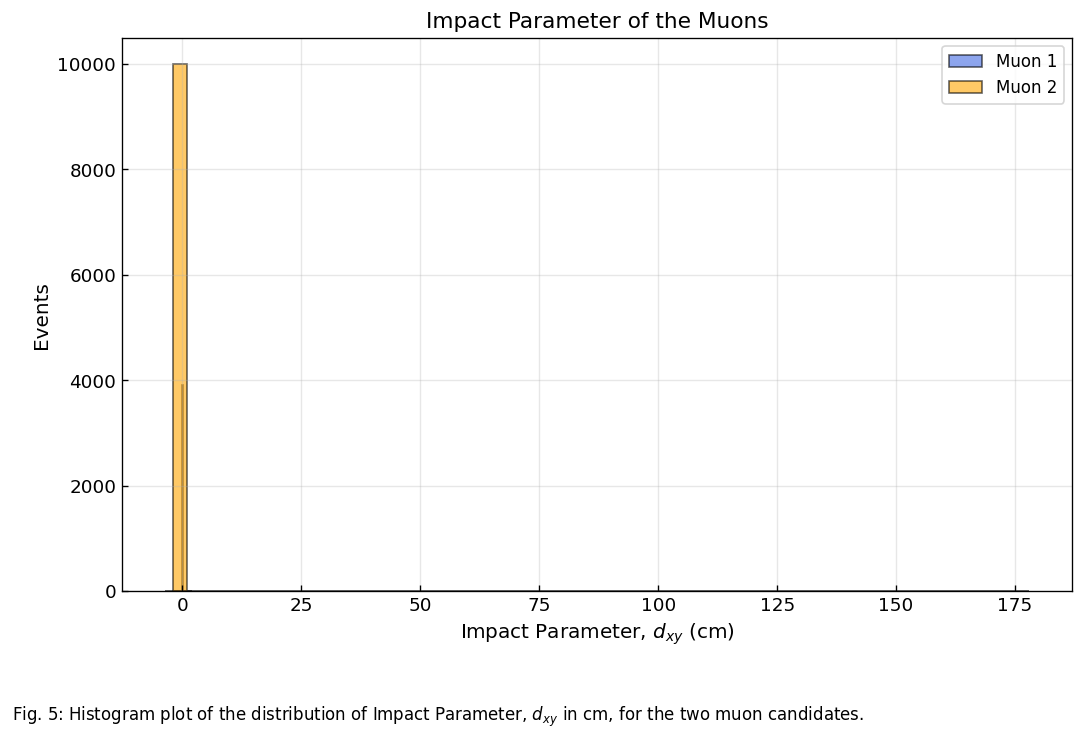

In [7]:
plot_overlay_histogram(
    zmumu["dxy1"],
    zmumu["dxy2"],
    bins=60,
    xlabel=r"Impact Parameter, $d_{xy}$ (cm)",
    title="Impact Parameter of the Muons",
    caption=r"Fig. 5: Histogram plot of the distribution of Impact Parameter, $d_{xy}$ in cm, for the two muon candidates."
)

The transverse impact parameter distributions for both reconstructed muons exhibit a pronounced peak centred close to zero, indicating that the majority of tracks originate from the primary proton–proton interaction vertex. This behaviour is expected for prompt muons produced directly in the decay of a $Z$ boson, whose decay occurs essentially at the collision point. Only a small number of events possess comparatively large impact parameters, forming the tails of the distributions. These are likely associated with reconstruction uncertainties or a small fraction of non-prompt tracks that remain within the pre-selected dataset. Overall, the distributions provide strong evidence that the reconstructed muons are of good quality and are consistent with the expected characteristics of prompt electroweak processes.

### 2.6 &nbsp; Isolation

The isolation variable provides a measure of the surrounding detector activity near a reconstructed muon by combining contributions from nearby charged-particle tracks and calorimeter energy deposits. Prompt muons originating directly from electroweak processes, such as $Z$-boson decays, are typically well isolated from other particles, whereas muons produced within jets are generally accompanied by significant additional activity. Consequently, the isolation variable plays an important role in distinguishing signal-like events from background processes and serves as a useful indicator of the overall quality of the reconstructed muon candidates.

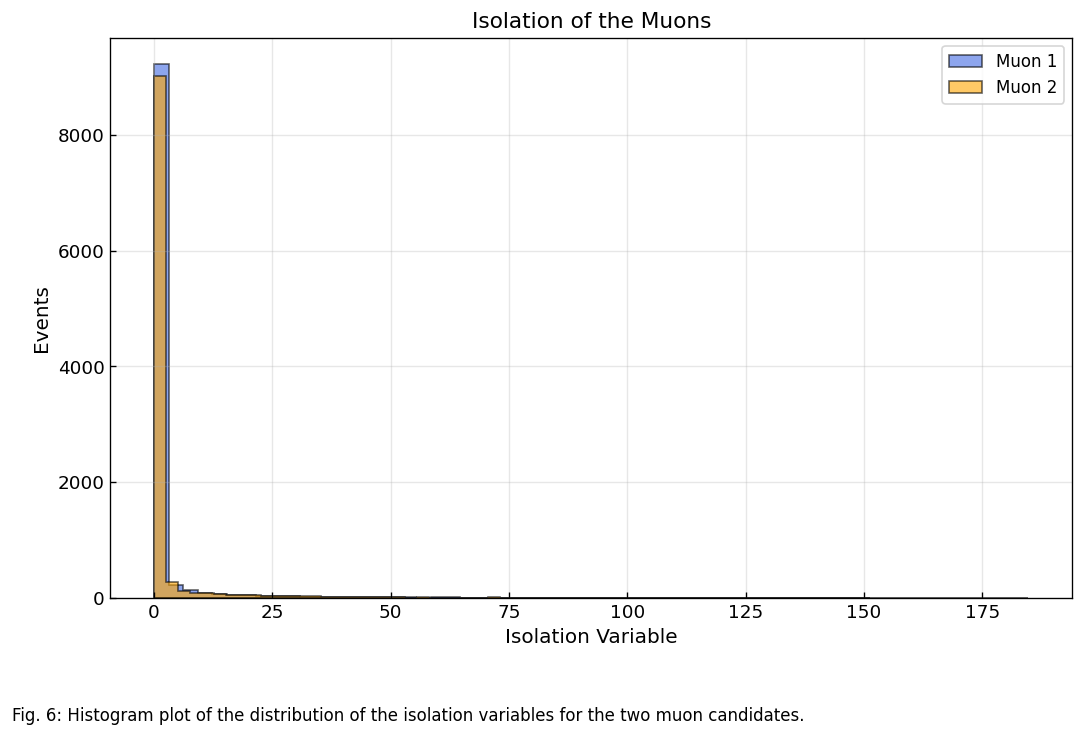

In [8]:
plot_overlay_histogram(
    zmumu["iso1"],
    zmumu["iso2"],
    bins=60,
    xlabel=r"Isolation Variable",
    title="Isolation of the Muons",
    caption=r"Fig. 6: Histogram plot of the distribution of the isolation variables for the two muon candidates."
)

The isolation distributions display a sharp peak at values close to zero, accompanied by a gradually decreasing tail extending towards larger isolation values. This indicates that the majority of reconstructed muons are well isolated from surrounding detector activity, as expected for prompt muons originating from $Z$-boson decays. The comparatively small number of events with larger isolation values likely correspond to muons reconstructed in regions with increased nearby particle activity or residual background contributions. The predominance of low-isolation muons therefore provides further confidence that the dataset is dominated by genuine $Z \rightarrow \mu^+\mu^-$ candidate events rather than hadronic background processes.

## 3. &nbsp; Correlation Analysis

### 3.1 &nbsp; Transverse Momentum Correlation

While one-dimensional distributions provide valuable insight into the individual properties of reconstructed particles, they do not reveal how different observables are related to one another. Correlation analysis examines the degree to which pairs of variables vary together, helping to identify underlying relationships within the dataset. In this section, a scatter plot is first used to examine the relationship between the transverse momenta of the two reconstructed muons, followed by a correlation matrix that quantifies the degree of linear correlation between the principal reconstructed observables.

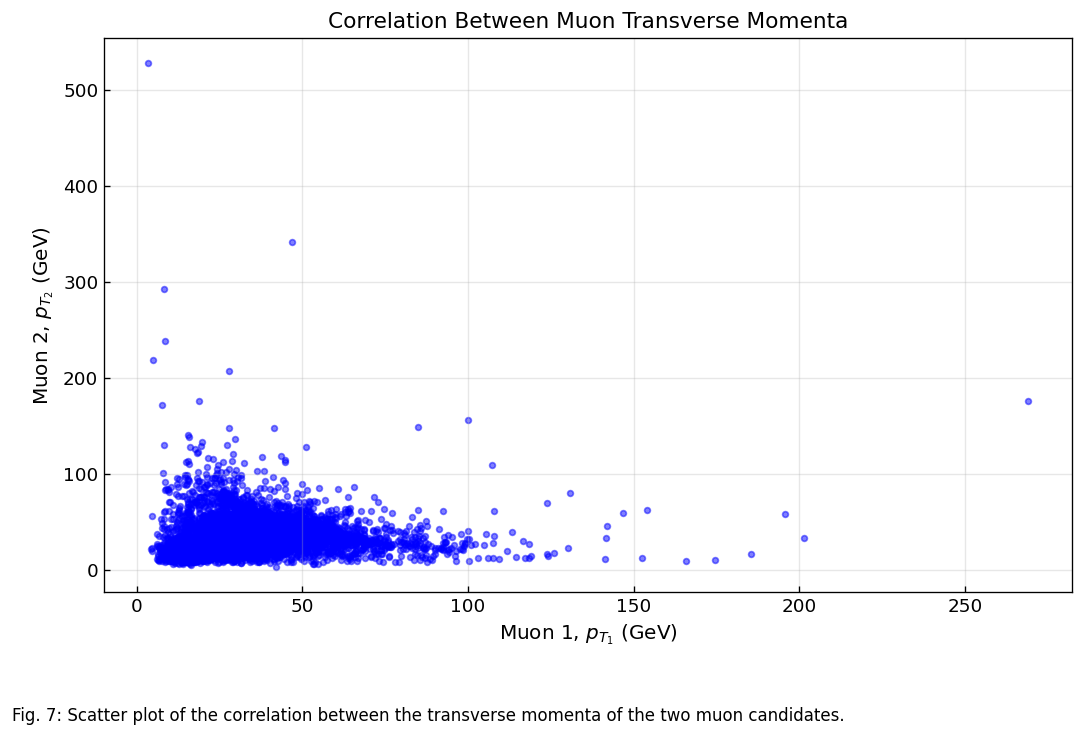

In [9]:
plot_scatter(
    zmumu["pt1"],
    zmumu["pt2"],
    xlabel=r"Muon 1, $p_{T_1}$ (GeV)",
    ylabel=r"Muon 2, $p_{T_2}$ (GeV)",
    title="Correlation Between Muon Transverse Momenta",
    caption=r"Fig. 7: Scatter plot of the correlation between the transverse momenta of the two muon candidates."
)

The scatter plot demonstrates the relationship between the transverse momenta of the two reconstructed muons within each event. Although the individual momenta span a broad range of values, both muons are observed to occupy similar kinematic regions, with the majority of events clustered at transverse momenta of a few tens of GeV. No strong linear relationship is evident, indicating that the momentum of one reconstructed muon does not uniquely determine that of the other. This behaviour is consistent with the kinematics of two-body decays produced with varying boosts in proton–proton collisions, where the observed transverse momenta depend on both the decay geometry and the motion of the parent $Z$-boson.


### 3.2 &nbsp; Correlation Matrix

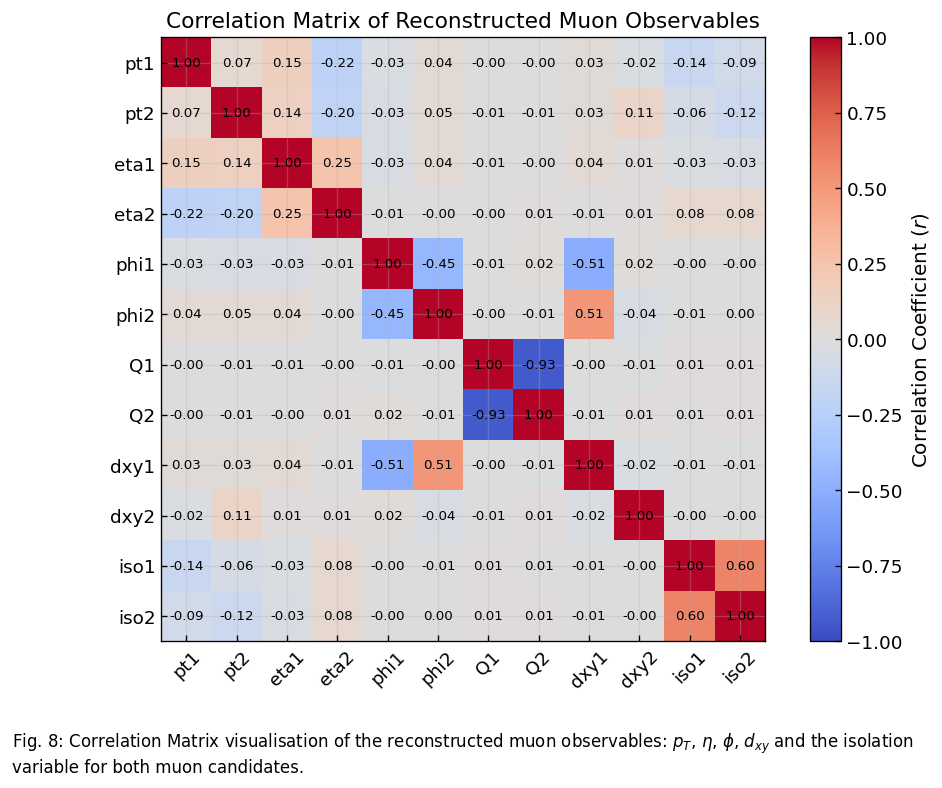

In [10]:
corr = zmumu[
    KINEMATIC_COLUMNS + 
    TRACK_COLUMNS
].corr()

plot_correlation_matrix(
    corr,
    title="Correlation Matrix of Reconstructed Muon Observables",
    label=r"Correlation Coefficient ($r$)",
    caption=r"Fig. 8: Correlation Matrix visualisation of the reconstructed muon observables: $p_T$, $\eta$, $\phi$, $d_{xy}$ and the isolation variable for both muon candidates."
)

The correlation matrix indicates that the majority of reconstructed observables exhibit only weak linear correlations, suggesting that each variable provides largely independent information about the reconstructed muons. This is expected, as the dataset contains measurements describing different physical properties of the particles, including their momentum, direction and track quality.

The strongest positive correlation is observed between the isolation variables of the two reconstructed muons $(r \approx 0.60)$. This suggests that the surrounding detector activity experienced by one muon is often similar to that of the other, reflecting the common collision environment from which both particles originate.

A moderate positive correlation is also present between the pseudorapidities of the two muons $(r \approx 0.25)$, indicating a slight tendency for both particles to be reconstructed in similar regions of the detector. Conversely, the transverse momenta exhibit only weak positive correlations $(r \approx 0.07)$, demonstrating that the momentum of one reconstructed muon does not strongly determine that of the other.


Overall, the correlation matrix does not reveal any unexpectedly strong dependencies between the reconstructed observables. The variables therefore provide complementary information for the subsequent invariant mass reconstruction and analysis.


#### Interpretation of Correlation between the Azimuthal Angle and the Transverse Impact Parameter

The azimuthal angle of the first muon and the transverse impact parameter of the first muon display a moderate negative correlation $(r \approx -0.51)$, while the second muon exhibits a corresponding positive correlation $(r \approx 0.51)$.

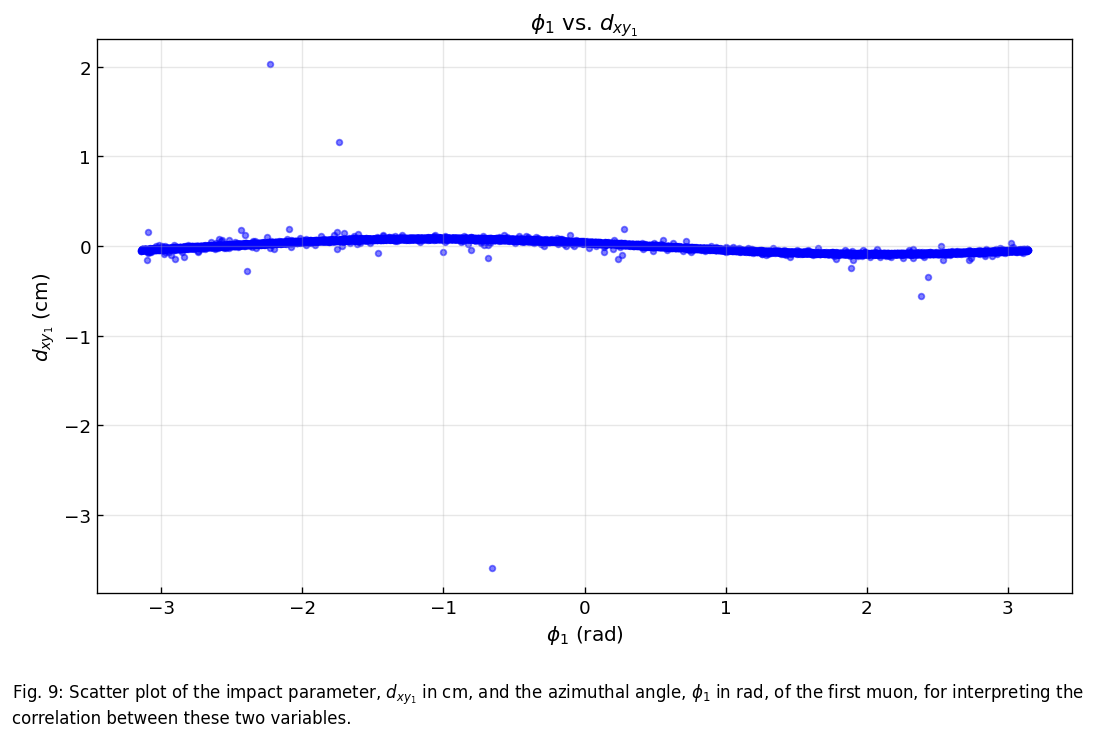

In [11]:
plot_scatter(
    zmumu["phi1"],
    zmumu["dxy1"],
    xlabel=r"$\phi_1$ (rad)",
    ylabel=r"$d_{{xy}_1}$ (cm)",
    title=r"$\phi_1$ vs. $d_{{xy}_1}$",
    caption=r"Fig. 9: Scatter plot of the impact parameter, $d_{xy_{1}}$ in cm, and the azimuthal angle, $\phi_1$ in rad, of the first muon, for interpreting the correlation between these two variables."
)

This moderate correlation observed is not indicative of a direct physical relationship between these quantities. Inspection of the corresponding scatter plot between these quantities for the first muon shows that the reconstructed tracks remain tightly clustered around $d_{xy}=0$ for all azimuthal angles, with only a slight systematic variation across the detector. This behaviour is more consistent with detector geometry and reconstruction effects than with any underlying feature of the $Z \rightarrow \mu^+\mu^-$ decay itself. Consequently, the observed correlation is unlikely to influence the subsequent invariant mass reconstruction.

## 4. &nbsp; Conclusion

This notebook has provided an exploratory analysis of the reconstructed muon observables contained within the simplified CMS Open Data sample. The distributions of the transverse momentum, pseudorapidity and azimuthal angle were found to be consistent with the expected kinematic properties of muons produced in high-energy proton–proton collisions, while the charge distribution confirmed the presence of oppositely charged muon pairs characteristic of $Z \rightarrow \mu^+\mu^-$ candidate events.

The impact parameter distributions exhibited a pronounced peak near the primary interaction vertex, indicating that the reconstructed muons predominantly originate from prompt production rather than secondary decays. Similarly, the isolation variables were strongly concentrated at low values, providing further evidence that the selected muons are well isolated from surrounding detector activity and are therefore consistent with the expected signature of electroweak $Z$-boson decays.

Correlation studies demonstrated that the majority of reconstructed observables are only weakly correlated, suggesting that they provide complementary information about each event. The strongest positive correlation was observed between the isolation variables of the two muons, reflecting the common collision environment from which both particles originate. No unexpected or anomalously strong correlations were identified that would indicate significant systematic effects or inconsistencies within the simplified dataset.

Overall, the exploratory analysis confirms that the reconstructed event sample exhibits the expected physical characteristics of high-quality $Z \rightarrow \mu^+\mu^-$ candidate events. Having established the integrity and behaviour of the measured observables, the analysis of the project is now well-prepared to proceed to the reconstruction of the invariant mass spectrum, where the characteristic $Z$-boson resonance can be identified and compared using both the exact relativistic expression and the massless approximation.